# Logistic Regression with Scikit-Learn

In [38]:
import pandas as pd

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [9]:
# some observations
data = {
    'StudyHour': [1, 2, 3, 4, 5, 6, 7, 8],
    'Pass':  ['N', 'N', 'N', 'N', 'Y', 'Y', 'Y', 'Y']
}

# convert to dataframe format
df = pd.DataFrame(data)

df.head()

,StudyHour,Pass
0,1,N
1,2,N
2,3,N
3,4,N
4,5,Y


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   StudyHour  8 non-null      int64
 1   Pass       8 non-null      str  
dtypes: int64(1), str(1)
memory usage: 268.0 bytes


In [11]:
# replace letters to number values

df['Pass'] = df['Pass'].map({"N": 0, "Y": 1})

# X and y, easier to call
X = df[['StudyHour']]   # predictor
y = df['Pass']      # target


In [28]:
model = LogisticRegression()
model.fit(X, y)

print("Classes:", model.classes_)
print("Intercept:", model.intercept_[0])
print("Balance coefficient:", model.coef_)


Classes: [0 1]
Intercept: -5.264107913297967
Balance coefficient: [[1.16979937]]


In [35]:
# predicted probability
y_pred = model.predict(X)
prob = model.predict_proba(X)
prob

array([[0.98360598, 0.01639402],
       [0.9490448 , 0.0509552 ],
       [0.85254586, 0.14745414],
       [0.64219651, 0.35780349],
       [0.35780843, 0.64219157],
       [0.14745684, 0.85254316],
       [0.05095624, 0.94904376],
       [0.01639437, 0.98360563]])

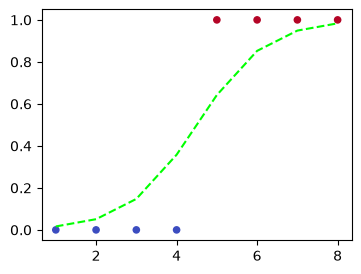

In [36]:
# visualize the data and the predictions

plt.figure(figsize=(4, 3))
plt.scatter(X, y, s=20, c=y,cmap="coolwarm")
plt.plot(X, prob[:,1], color='lime', linestyle='--')
plt.show()

# plot the smoother function
#arr = pd.DataFrame({"StudyHour": np.linspace(0, 10, 50)})
#arr_prob = model.predict_proba(arr)
#plt.plot(arr, arr_prob[:,1], color='blue', linestyle='--')


In [43]:
# performance evaluation

acc = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
mcc = matthews_corrcoef(y, y_pred)
cm = confusion_matrix(y, y_pred)

print(f'Acc = {acc:.4f}')
print(f'F1 = {f1:.4f}')
print(f'MCC = {mcc:.4f}')


Acc = 1.0000
F1 = 1.0000
MCC = 1.0000


In [44]:
print(cm)

[[4 0]
 [0 4]]


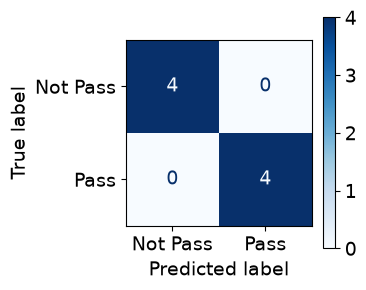

In [58]:
"""
plt.rcParams.update({
    'font.size':14
})
"""

fig, ax = plt.subplots(figsize=(3, 3))
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Pass", "Pass"])
disp.plot(ax=ax, cmap="Blues")